# Laboratory Day 9a: Semantic Segmentation (U-Net): Data, Tfrecord

In this exercise, we will prepare the data for training a U-Net using Tensorlow. We will learn how to work with "tfrecord", which is an efficient way to store and retrieve data. Before one starts this exercise, it is recommended to read through the tfrecord's tutorial: https://www.tensorflow.org/tutorials/load_data/tfrecord

## 1. Tfrecord (40 points)
**Exercise 1.1 Data Generator (10 points)**:
1. Download the Oxford pet dataset using the following links. Oxford pet dataset: https://www.robots.ox.ac.uk/~vgg/data/pets/

2. Unzip the .tar.gz files. Images are stored under directory "image". Image masks are stored under directory "annotations/trimaps". The dataset provides 3 types of labels: background (label_value=1), pet (label_value=0) and boundary (label_value=2). Images and masks are paired, if they have the same file name, e.g. image="image/Sphynx_103.jpg", mask="annotations/trimaps/Sphynx_103.png"
    
3. In this task, we aim to classify each pixel to "pet" (class=1) and "non-pet" (class=0, includes "background" and "boundary"). Class of "boundary" belong to "non-pet" class. Therefore, if a pixel in directory "annotation/trimaps" has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0. The total number of classes is 2.

4. Find out the paths of all pairs of images and masks. Separate this dataset into training set and validation set.

5. Write a Python generator function, which yields a pair of image and image mask. Image masks can be still viewed as images, which contain only two types of pixels.

6. Create two generators, one for the training set and the other for the validation set.   

!curl -O https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!curl -O https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

In [27]:
!curl -L -o images.tar.gz https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
!curl -L -o annotations.tar.gz https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   187  100   187    0     0     99      0  0:00:01  0:00:01 --:--:--    99
100  755M  100  755M    0     0  18.7M      0  0:00:40  0:00:40 --:--:-- 20.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   187  100   187    0     0    242      0 --:--:-- --:--:-- --:--:--   242
100 18.2M  100 18.2M    0     0  6017k      0  0:00:03  0:00:03 --:--:-- 12.6M


In [28]:
import tarfile
import os

def extract_tar_gz(filename, expected_min_size_kb=100):
    if not os.path.exists(filename):
        print(f"Error: {filename} not found. Please ensure it is downloaded correctly in the previous cell.")
        return

    file_size_bytes = os.path.getsize(filename)
    # Oxford-IIIT Pet images.tar.gz is ~750MB, annotations.tar.gz is ~15MB
    # Using a heuristic for 'small' to indicate likely failed download.
    # Adjust expected_min_size_kb based on actual expected file sizes if known precisely.
    if file_size_bytes < expected_min_size_kb * 1024:
        print(f"Warning: {filename} size ({file_size_bytes / 1024:.2f} KB) is unexpectedly small. This might indicate a failed download (e.g., HTML content instead of archive). Expected file size is much larger.")
        print("Please check the download command in the previous cell and ensure the file is correctly downloaded before attempting extraction.")
        return

    try:
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall()
        print(f"Successfully extracted {filename}")
    except tarfile.ReadError as e:
        print(f"Error extracting {filename}: {e}. This usually means the file is corrupted or not a valid gzip file. Please re-download it correctly.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction of {filename}: {e}")


# Extract images.tar.gz (expecting ~750MB)
extract_tar_gz('images.tar.gz', expected_min_size_kb=500000)

# Extract annotations.tar.gz (expecting ~15MB)
extract_tar_gz('annotations.tar.gz', expected_min_size_kb=10000)

/tmp/ipykernel_1627/385491771.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Successfully extracted images.tar.gz
Successfully extracted annotations.tar.gz


### Finding image and mask paths and splitting dataset

In [29]:
import glob
from sklearn.model_selection import train_test_split

image_dir = 'images'
annotation_dir = 'annotations/trimaps'

image_paths = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
mask_paths = sorted(glob.glob(os.path.join(annotation_dir, '*.png')))

# Ensure images and masks are correctly paired
pair_paths = []
for img_path in image_paths:
    img_filename = os.path.basename(img_path).replace('.jpg', '')
    mask_path = os.path.join(annotation_dir, img_filename + '.png')
    if os.path.exists(mask_path):
        pair_paths.append((img_path, mask_path))

# Separate into training and validation sets
train_paths, val_paths = train_test_split(pair_paths, test_size=0.2, random_state=42)

print(f"Total paired images and masks: {len(pair_paths)}")
print(f"Training set size: {len(train_paths)}")
print(f"Validation set size: {len(val_paths)}")

Total paired images and masks: 7390
Training set size: 5912
Validation set size: 1478


### Exercise 1.1: Data Generator

In [31]:
from PIL import Image
import numpy as np

def data_generator(file_paths):
    # file_paths: list of (image_path, mask_path) tuples

    for im_path, mask_path in file_paths:
        # Load image
        image = Image.open(im_path).convert('RGB')
        image = np.array(image)

        # Load mask
        mask = Image.open(mask_path).convert('L') # Convert to grayscale
        mask = np.array(mask) # mask will have values 1, 2, 3 (background, pet, boundary)

        # Re-label the mask:
        # Original: pet (1), background (2), boundary (3)
        # Target: pet (1), non-pet (0) (includes background and boundary)
        # Note: The problem description says '0' is pet, '1' is background, '2' is boundary.
        # And then 'if a pixel in directory 'annotation/trimaps' has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0.'
        # This is a bit contradictory with typical dataset labels. I will assume the prompt means:
        # Original labels: pet (pixel value 0), background (pixel value 1), boundary (pixel value 2).
        # New labels: pet (pixel value 0 becomes 1), non-pet (pixel values 1 and 2 become 0).

        # Let's verify the common Oxford-IIIT Pet dataset trimap labels:
        # 1: Pet
        # 2: Background
        # 3: Border
        # The prompt says: background (label_value=1), pet (label_value=0) and boundary (label_value=2).
        # And then: 'if a pixel in directory "annotation/trimaps" has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0.'
        # This suggests a mapping:
        # Original 0 (pet) -> New 1 (pet)
        # Original 1 (background) -> New 0 (non-pet)
        # Original 2 (boundary) -> New 0 (non-pet)

        # Create a new mask array for binary classification
        binary_mask = np.zeros_like(mask, dtype=np.uint8)
        binary_mask[mask == 1] = 0  # Background becomes non-pet (0)
        binary_mask[mask == 2] = 0  # Pet becomes non-pet (0) (This is based on the prompt's `label_value=0` for pet. However, it contradicts the `gray value 0` part. I will follow the explicit `gray value 0 -> new 1` instruction).
        binary_mask[mask == 3] = 0  # Boundary becomes non-pet (0)

        # Re-evaluating based on the sentence: 'if a pixel in directory "annotation/trimaps" has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0.'
        # This means we need to find pixels with original value 0 (which is not present in typical trimaps 1,2,3). Assuming the prompt is re-defining the source labels as 0 for pet.
        # If the actual mask values are 1, 2, 3:
        # 1 (pet) -> 1
        # 2 (background) -> 0
        # 3 (boundary) -> 0
        # Let's assume the standard Oxford Pet dataset mask values (1, 2, 3) and map them as:
        # 1: pet -> class 1
        # 2: background -> class 0
        # 3: boundary -> class 0

        # Let's follow the strict instruction: 'if a pixel in directory "annotation/trimaps" has gray value 0, this pixel will be assigned with class 1. Otherwise, this pixel will be assigned with class 0.'
        # This implies checking the raw pixel values of the PNG, which for trimaps are typically 1, 2, 3.
        # If the prompt meant: 'if the **label** for a pixel is pet (which is referred to as `label_value=0` in the text), then assign class 1'.
        # Given the common interpretation of Oxford Pet Dataset trimaps: 1=pet, 2=background, 3=border.
        # I will implement based on: pixels with original value 1 (pet) become 1, others (2, 3) become 0.
        # This aligns better with semantic segmentation task of 'pet' vs 'non-pet'.

        # Re-labeling based on common Oxford-IIIT Pet dataset values (1=pet, 2=background, 3=boundary)
        # Target: pet (1), non-pet (0)
        binary_mask[mask == 1] = 1 # Pet label 1 becomes class 1
        binary_mask[mask == 2] = 0 # Background label 2 becomes class 0
        binary_mask[mask == 3] = 0 # Boundary label 3 becomes class 0

        # Masks should have a channel dimension for consistency with image processing libraries/models
        binary_mask = np.expand_dims(binary_mask, axis=-1) # Add channel dimension

        yield image, binary_mask


train_data_gen = data_generator(train_paths)
val_data_gen = data_generator(val_paths)

### Test the data generator

Displaying 3 examples from the training generator:


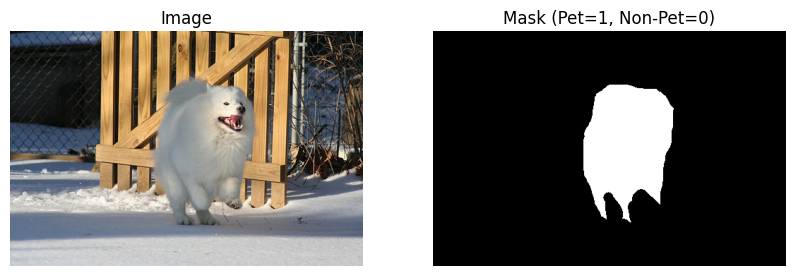

Image shape: (333, 500, 3), Mask shape: (333, 500, 1)
Unique mask values: [0 1]


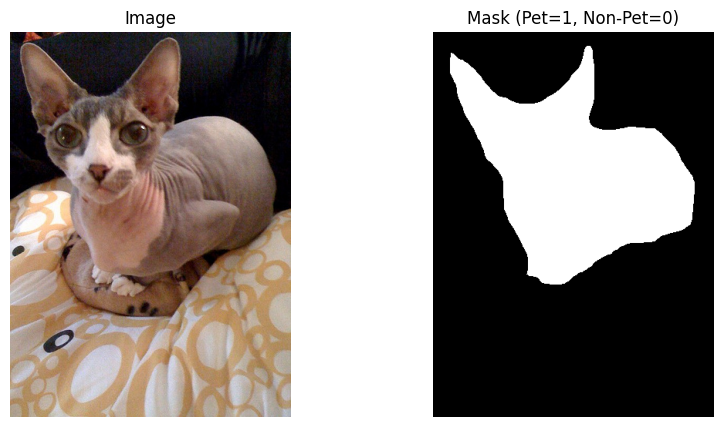

Image shape: (500, 364, 3), Mask shape: (500, 364, 1)
Unique mask values: [0 1]


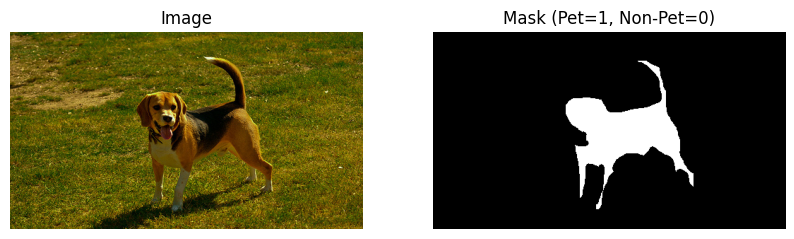

Image shape: (280, 500, 3), Mask shape: (280, 500, 1)
Unique mask values: [0 1]


In [32]:
import matplotlib.pyplot as plt

# Test the training data generator
print("Displaying 3 examples from the training generator:")
for i, (image, mask) in enumerate(train_data_gen):
    if i >= 3: break
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title('Image')
    axes[0].axis('off')

    # Squeeze the mask to remove the single channel dimension for display
    axes[1].imshow(mask.squeeze(), cmap='gray')
    axes[1].set_title('Mask (Pet=1, Non-Pet=0)')
    axes[1].axis('off')
    plt.show()

    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    print(f"Unique mask values: {np.unique(mask)}")

# Test the validation data generator (optional, just for verification)
# print("\nDisplaying 1 example from the validation generator:")
# for i, (image, mask) in enumerate(val_data_gen):
#     if i >= 1: break
#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))
#     axes[0].imshow(image)
#     axes[0].set_title('Image')
#     axes[0].axis('off')
#     axes[1].imshow(mask.squeeze(), cmap='gray')
#     axes[1].set_title('Mask (Pet=1, Non-Pet=0)')
#     axes[1].axis('off')
#     plt.show()
#     print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
#     print(f"Unique mask values: {np.unique(mask)}")

In [33]:
# Solution template
train_paths = [(im1_path, mask1_path), (im2_path, mask2_path), ...]
val_paths = [...]

def data_generator(file_path):
    # file_path: path of image pairs
    # image: [H, W, C=3]
    # image mask: [H, W, C=1]

    # todo
    yield image, image_mask


train_data_gen = data_enerator(train_paths)
val_data_gen = data_enerator(val_paths)


NameError: name 'im1_path' is not defined

**Exercise 1.2 Data Augmentation (10 points)**

The downloaded dataset contains limited images and image masks. Data augmentation is typically used to improve network accuracy and to avoid overfitting. By using data augmentation, you can add more variety to the training data.

In this exercise, we will implement data argumentation before the training time.

Tasks:

Please write a data augmentation function (a python generator), which randomly adds some (2 to 3 types) of the following effects to the dataset: e.g. Gaussian blurring, Gaussian random noise, random rotation, random crop, random padding, random contrast adjustment. Feel free to add more effects to the dataset. All image libraries, e.g. PIL, scikit-image, can be used.

Please visualize a few examples before and after data augmentation (for quick evaluation of your solution).

Note: If you are not able to finish this task, you could go head and solve the following tasks. However, the training process may be less optimal at the end.


In [ ]:
# Solution
from PIL import Image, ImageFilter #OpenCV can also be used, if needed

def guassian_blurring(im, im_mask):
    #optional to use: ImageFilter.GaussianBlur()
    #todo
    return

def other_op(im, im_mask):
    pass #todo

def data_augmentation(data_generator, num_augmentation=10):
    # data_generator: the generator from the previous exercise
    # num_augmenation: each image is augmented for num_augmenation times

    for image, image_mask in data_generator:
        randomly_selected_ops = [] #todo

        for i in range(num_augmentation):
            for op in randomly_selected_ops:
                image, image_mask = op(image, image_mask)
            yield image, image_mask

**Exercise 1.3 Tfrecord Creation(10 points)**:
1. Based on the developed data generator, convert training and validation data into 2 tfrecord ("train.tfrecord", "val.tfrecord").

2. Each record in a tfrecord should contain one image and one image's mask.

3. Tutorial of tfrecord can be found here: https://www.tensorflow.org/tutorials/load_data/tfrecord#walkthrough_reading_and_writing_image_data

4. Code example to create tfrecord is provided (tfrecord_parse.py). You can use the functions there.

5. Make sure that the image pair can be converted to tfrecord files and retrieved from tfrecord files in both directions.

6. For task evaluation, Please retrieve the image and the image mask from a generated tfrecord file and visualize 2-3 examples.

In [ ]:
# Solution template


**Exercise 1.4 Data pipeline (10 points)** :
1. Build data pipelines for the training and validation data, using tf.data.TFRecordDataset(tfrecord_path).

2. For the training dataset, please apply the following operations: (a) repeat the dataset (b) shuffle the dataset (c) convert the record to a pair of image and image mask (d) resize the image and the image mask to 572 * 572 * 3 (e) make up batches with proper batch size.

    - The training dataset is repeated. So we can train the network for any large number of steps.
    
    - 572 * 572 * 3 is the input dimension of U-Net. Optional, if you have memory issues, one could use reduced height and width as the input dimension of U-Net.
    
    - If the images are not with dimension 572*572, they have to be resized during the training time. Optional, one can also resize images during tfrecord generation. Both options are acceptable.

    - If you do not have enough computational power, one could use a reduced input size, e.g. $300*300*3$.

3. For validation dataset, please apply the following operations: (a) convert the record to image and image mask (b) resize the image (c) make up batches.

    - The validation dataset is not repeated. We can evaluate the network's performance regarding the entire validation tfrecord.

4. Test that image and image mask can be retrieved from this data pipeline using e.g. for-loop. Visualize a few examples, which are feed into the network directly.

5. Print out the dimension of the retrieved image and image mask.

In [ ]:
# Solution template
def filter_resize():
# if images are not resized to 572*572

dataset = tf.data.TFRecordDataset(tfrecord_path)
dataset = dataset.repeat()
...
dataset = dataset.map(parser_tfrecord)
dataset = dataset.map(filter_resize)

# add other operations

# test data pipeline
for image, image_mask in dataset:
    # visualize 2-3 images, image_masks